## Data Analysis


### Learning objectives
By the end of this activity, you should be able to:

1. Explain the purpose of each major Python step.
2. Inspect a dataset before analysing it.
3. Select visualisations that answer a specific analytical question.
4. Interpret a chart rather than merely describe its appearance.
5. Distinguish **observation, association, and causation**.
6. Communicate findings in clear analytical language.



## 1. Before running the notebook

A useful habit in data analytics is to decide what we are trying to learn **before** creating charts.

For every visualisation, ask:

- **What question does this chart answer?**
- **Why is this chart type appropriate?**
- **What pattern should I look for?**
- **What can I legitimately conclude?**
- **What can I *not* conclude from this chart alone?**

This prevents EDA from becoming a collection of attractive but unrelated plots.


**Analytical question:** Which libraries do we need, and what role does each one play?

**Why we are doing this:** Set up the Python environment and import the libraries needed for the activity.

Predict what the output might show?


In [1]:
# Step 1: Import Necessary Libraries
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import nltk

# Download stopwords from NLTK
nltk.download('stopwords')
from nltk.corpus import stopwords


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/avfrad/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#### How to interpret this visualisation

Do not stop at *“the chart goes up/down”*. Interpret it in four steps:

1. **Identify** — What variables are shown?
2. **Describe** — What is the main pattern, difference, cluster, or unusual observation?
3. **Interpret** — What might that pattern mean in the context of the dataset?
4. **Limit** — What conclusion would be too strong?

A good answer follows this structure:

> “The visualisation shows that **[observable pattern]**. This suggests an **association** between **[variables]**. However, the chart alone does not establish that one variable **causes** the other.”

**Discussion:** Is this the best chart for the analytical question? What alternative visualisation could communicate the pattern more clearly?


### Checkpoint

**Analytical question:** What does the dataset contain, and are there any immediate data-quality issues?

**Why we are doing this:** Inspect the dataset before performing deeper analysis.

Predict what the output might show?


In [2]:
# Step 2: Load the mpox dataset
df = pd.read_csv('reddit_monkeypox.csv')

# Display the first few rows of the dataset
df.head()


,title,score,id,url,comms_num,created,body,year-month-day,hour-min-sec
0,Monkeypox may be on its way to a school near you,101,wtgjsb,https://thehill.com/opinion/healthcare/3607622...,33,1661026996,NaN,2022-08-21,4:23:16
1,Purpose of Home Disinfection,29,wt923l,https://www.cdc.gov/poxvirus/monkeypox/specifi...,18,1661007372,NaN,2022-08-20,22:56:12
2,Lack of ‘high quality’ clinical guidelines for...,45,wsu8pe,https://thehill.com/changing-america/well-bein...,2,1660957502,NaN,2022-08-20,9:05:02
3,California issues monkeypox quarantine guidelines,135,wsn73d,https://www.kron4.com/monkeypox/california-iss...,31,1660938749,NaN,2022-08-20,3:52:29
4,EU backs changing monkeypox vaccine injection ...,2,wsn2my,https://www.reuters.com/business/healthcare-ph...,4,1660938429,NaN,2022-08-20,3:47:09


### Checkpoint

**Analytical question:** What does this step contribute to the overall analysis?

**Why we are doing this:** Perform the next analytical step from the original activity.

Predict what the output might show.


In [3]:
# Step 3: Data Preprocessing
# Combine all the symptom descriptions into a single string
# Replace 'Symptom_Description' with the actual column name in your dataset
text = " ".join(text for text in df['title'])

# Define stopwords
custom_stopwords = set(stopwords.words('english')).union(STOPWORDS)

# Add more stopwords if necessary
# custom_stopwords.update(['disease', 'symptom', 'patient', 'treatment'])  # Example of adding more stopwords


### Checkpoint

**Analytical question:** What does this step contribute to the overall analysis?

**Why we are doing this:** Perform the next analytical step from the original activity.

Predict what the output might show?


In [4]:
# Step 4: Generate the Word Cloud
wordcloud = WordCloud(stopwords=custom_stopwords, background_color='white', max_words=100, width=800, height=400).generate(text)


### Checkpoint

**Analytical question:** What analytical question is this visualisation intended to answer?

**Why we are doing this:** Use a visualisation to reveal a pattern that is difficult to see in a table.

Predict what the output might show?


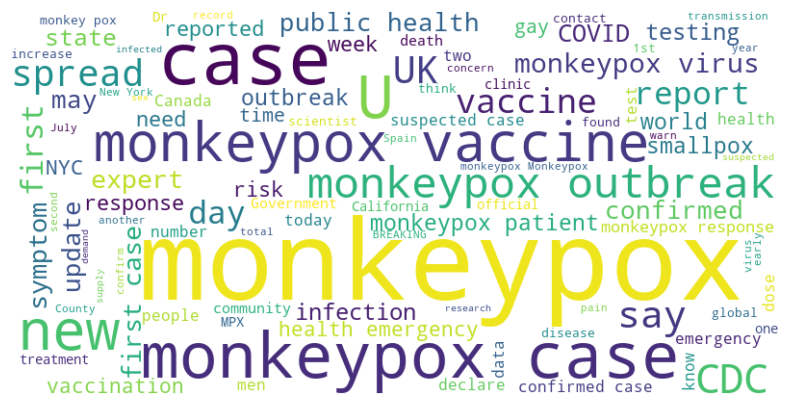

In [5]:
# Step 5: Plot the Word Cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off axis
plt.show()


#### How to interpret this visualisation

Do not stop at *“the chart goes up/down”*. Interpret it in four steps:

1. **Identify** — What variables are shown?
2. **Describe** — What is the main pattern, difference, cluster, or unusual observation?
3. **Interpret** — What might that pattern mean in the context of the dataset?
4. **Limit** — What conclusion would be too strong?

A good classroom answer follows this structure:

> “The visualisation shows that **[observable pattern]**. This suggests an **association** between **[variables]**. However, the chart alone does not establish that one variable **causes** the other.”

**Discussion:** Is this the best chart for the analytical question? What alternative visualisation could communicate the pattern more clearly?


Add custom stopwords in cell 7 and check the output.What insights can you gain.


## Improving the visual analysis

The next cells provide reusable, well visualisation patterns. They deliberately begin by checking the available numerical columns so that the plots are based on the actual dataset created earlier in the notebook.

The goal is not to produce more charts. The goal is to produce **more informative charts**.


In [6]:
# Identify a DataFrame created earlier in the notebook.
# This avoids hard-coding a new dataset and keeps the improved section tied
# to the original Activity 3 data.

dataframes = {
    name: obj for name, obj in globals().items()
    if isinstance(obj, pd.DataFrame)
}

if not dataframes:
    raise ValueError("No pandas DataFrame was found. Run the earlier activity cells first.")

# Use the largest DataFrame, which is usually the main analytical dataset.
df_teaching = max(dataframes.values(), key=len).copy()

print(f"Rows: {df_teaching.shape[0]:,}")
print(f"Columns: {df_teaching.shape[1]}")
display(df_teaching.head())


Rows: 965
Columns: 9


,title,score,id,url,comms_num,created,body,year-month-day,hour-min-sec
0,Monkeypox may be on its way to a school near you,101,wtgjsb,https://thehill.com/opinion/healthcare/3607622...,33,1661026996,NaN,2022-08-21,4:23:16
1,Purpose of Home Disinfection,29,wt923l,https://www.cdc.gov/poxvirus/monkeypox/specifi...,18,1661007372,NaN,2022-08-20,22:56:12
2,Lack of ‘high quality’ clinical guidelines for...,45,wsu8pe,https://thehill.com/changing-america/well-bein...,2,1660957502,NaN,2022-08-20,9:05:02
3,California issues monkeypox quarantine guidelines,135,wsn73d,https://www.kron4.com/monkeypox/california-iss...,31,1660938749,NaN,2022-08-20,3:52:29
4,EU backs changing monkeypox vaccine injection ...,2,wsn2my,https://www.reuters.com/business/healthcare-ph...,4,1660938429,NaN,2022-08-20,3:47:09


### Chart 1 — Distribution of a numerical variable

A histogram is useful when the question is:

> **How are the observations distributed?**

We are interested in the centre, spread, skewness, unusual values, and possible multiple peaks—not just the tallest bar.


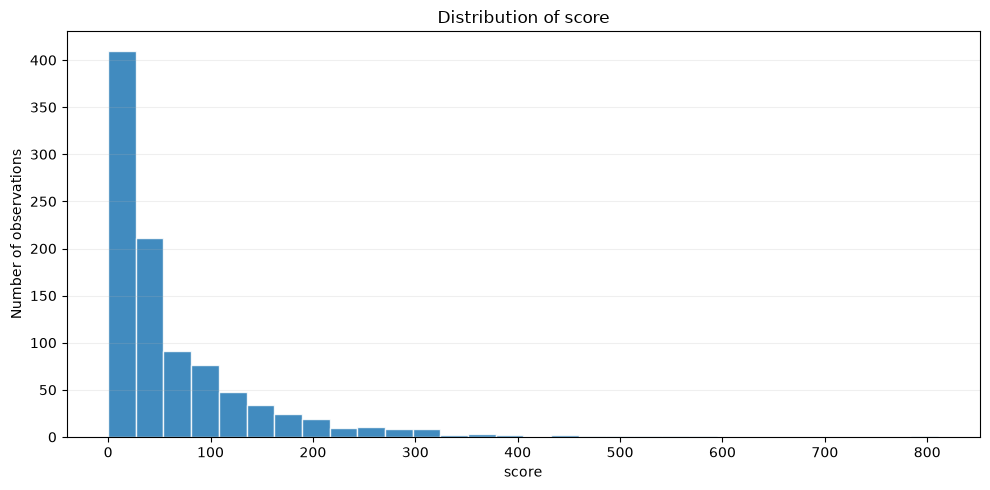

Median: 34.000
Mean:   64.730


In [7]:
numeric_cols = df_teaching.select_dtypes(include="number").columns.tolist()

if numeric_cols:
    feature = numeric_cols[0]

    ax = df_teaching[feature].dropna().plot(
        kind="hist",
        bins=30,
        figsize=(10, 5),
        edgecolor="white",
        alpha=0.85
    )

    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of observations")
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()

    print(f"Median: {df_teaching[feature].median():.3f}")
    print(f"Mean:   {df_teaching[feature].mean():.3f}")
else:
    print("No numerical columns are available for a histogram.")


#### Interpretation prompts

- Where are most observations concentrated?
- Is the distribution roughly symmetric or skewed?
- Are the mean and median similar?
- Are there possible extreme observations?
- Would the median be more informative than the mean here?

A histogram explains the *shape* of a variable. A single average cannot show that shape.


### Chart 2 — Relationship between two numerical variables

A scatter plot is appropriate when the question is:

> **Is there a relationship between two numerical variables?**

Transparency is used so that dense regions remain visible when observations overlap.


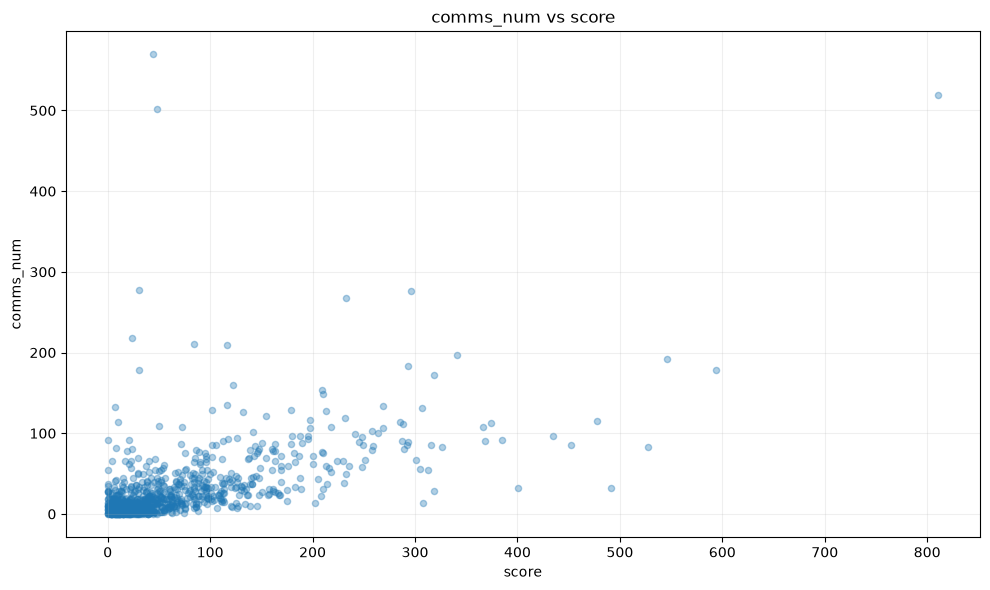

Pearson correlation: 0.577


In [8]:
if len(numeric_cols) >= 2:
    x_feature = numeric_cols[0]
    y_feature = numeric_cols[1]

    plot_data = df_teaching[[x_feature, y_feature]].dropna()

    # Sampling keeps very large datasets readable without changing the original data.
    if len(plot_data) > 5000:
        plot_data = plot_data.sample(5000, random_state=42)

    ax = plot_data.plot(
        kind="scatter",
        x=x_feature,
        y=y_feature,
        figsize=(10, 6),
        alpha=0.35
    )

    ax.set_title(f"{y_feature} vs {x_feature}")
    ax.set_xlabel(x_feature)
    ax.set_ylabel(y_feature)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    correlation = df_teaching[[x_feature, y_feature]].corr().iloc[0, 1]
    print(f"Pearson correlation: {correlation:.3f}")
else:
    print("At least two numerical columns are required for a scatter plot.")


#### Interpretation prompts

Look for:

- **Direction:** positive, negative, or no clear relationship?
- **Strength:** tightly grouped or widely dispersed?
- **Form:** approximately linear or curved?
- **Outliers:** observations far from the main pattern?
- **Clusters:** separate groups that may need further investigation?

A correlation coefficient complements the scatter plot, but it should **not replace the visualisation**.

> **Important:** Correlation measures association. It does not prove causation.


### Chart 3 — Ranked correlations

A full correlation heatmap can become visually busy. If the teaching objective is to identify the strongest numerical relationships, a **ranked bar chart** is often easier to interpret.

The following example uses the last numerical column as a reference variable. Change `target` if the activity has a clearly defined target variable.


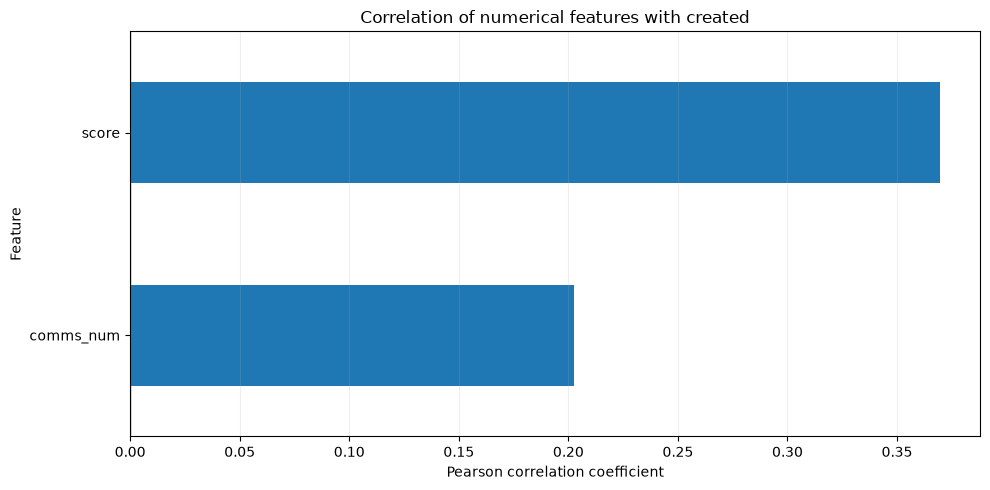

In [9]:
if len(numeric_cols) >= 3:
    target = numeric_cols[-1]

    correlations = (
        df_teaching[numeric_cols]
        .corr()[target]
        .drop(target)
        .sort_values()
    )

    ax = correlations.plot(
        kind="barh",
        figsize=(10, max(5, len(correlations) * 0.35))
    )

    ax.set_title(f"Correlation of numerical features with {target}")
    ax.set_xlabel("Pearson correlation coefficient")
    ax.set_ylabel("Feature")
    ax.axvline(0, linewidth=1)
    ax.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("At least three numerical columns are required for a useful correlation ranking.")


#### How to read the correlation chart

- Values near **+1** indicate a strong positive linear association.
- Values near **−1** indicate a strong negative linear association.
- Values near **0** indicate little **linear** association.
- A value near zero does **not** prove that two variables are unrelated; the relationship may be nonlinear.

**Classroom question:** Which feature would you investigate next, and what additional plot would you create before drawing a conclusion?


## Final analytical summary

At the end of an EDA activity, you should be able to communicate findings without referring to Python syntax.

A useful summary structure is:

1. **Dataset:** What does one row represent?
2. **Quality:** Were missing values, duplicates, or unusual observations found?
3. **Distribution:** Which variables have noteworthy distributions?
4. **Relationships:** Which associations appear most important?
5. **Evidence:** Which chart/statistic supports each observation?
6. **Limitations:** What cannot be concluded from this analysis?
7. **Next step:** What should be investigated or modelled next?

### Exit questions

1. Which visualisation in this activity was most informative, and why?
2. Give one example of an **observation** and one example of an **interpretation**.
3. Why is correlation not evidence of causation?
4. What information can a histogram reveal that `mean()` cannot?
5. If you had another 20 minutes with this dataset, what would you investigate next?

